In [ ]:
from google.colab import files
uploaded = files.upload()


Saving delhi_aqi_combined.csv to delhi_aqi_combined (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import io

In [ ]:
df = pd.read_csv(io.BytesIO(uploaded['delhi_aqi_combined (1).csv']))
df.head()

,datetime,location_lat,location_lon,co,no2,o3,pm10,pm25,so2,aqi,...,pressure,precipitation,rain,cloud_cover,wind_speed,wind_direction,wind_gusts,solar_radiation,direct_radiation,diffuse_radiation
0,2019-01-01 00:00:00,28.5355,77.3178,0.598089,23.626271,35.874847,108.281832,68.843636,6.493686,215.009684,...,994.6,0.0,0.0,0.0,8.8,279.0,11.9,0.0,0.0,0.0
1,2019-01-01 01:00:00,28.5355,77.3178,0.874050,21.877824,52.473342,110.226722,65.451836,6.146056,211.475071,...,994.3,0.0,0.0,0.0,8.9,284.0,12.2,0.0,0.0,0.0
2,2019-01-01 02:00:00,28.5355,77.3178,0.760226,24.014983,47.666183,94.536014,58.175413,4.823612,203.892273,...,993.9,0.0,0.0,0.0,8.4,280.0,11.9,0.0,0.0,0.0
3,2019-01-01 03:00:00,28.5355,77.3178,0.641405,40.657160,59.056543,106.661734,65.056997,6.068532,211.063608,...,993.7,0.0,0.0,0.0,7.2,276.0,10.8,0.0,0.0,0.0
4,2019-01-01 04:00:00,28.5355,77.3178,1.006203,34.372253,47.741928,110.266831,70.506701,6.406905,216.742773,...,993.0,0.0,0.0,0.0,6.1,270.0,10.4,0.0,0.0,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43825 entries, 0 to 43824
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   datetime           43825 non-null  object 
 1   location_lat       43825 non-null  float64
 2   location_lon       43825 non-null  float64
 3   co                 43825 non-null  float64
 4   no2                43825 non-null  float64
 5   o3                 43825 non-null  float64
 6   pm10               43825 non-null  float64
 7   pm25               43825 non-null  float64
 8   so2                43825 non-null  float64
 9   aqi                43825 non-null  float64
 10  hour               43825 non-null  float64
 11  day                43825 non-null  float64
 12  month              43825 non-null  float64
 13  year               43825 non-null  float64
 14  day_of_week        43825 non-null  float64
 15  is_weekend         43825 non-null  float64
 16  temperature        438

In [ ]:
df.describe()

,location_lat,location_lon,co,no2,o3,pm10,pm25,so2,aqi,hour,...,pressure,precipitation,rain,cloud_cover,wind_speed,wind_direction,wind_gusts,solar_radiation,direct_radiation,diffuse_radiation
count,4.382500e+04,4.382500e+04,43825.000000,43825.000000,43825.000000,43825.000000,43825.000000,43825.000000,43825.000000,43825.000000,...,43825.000000,43825.000000,43825.000000,43825.000000,43825.000000,43825.000000,43825.000000,43825.000000,43825.000000,43825.000000
mean,2.853550e+01,7.731780e+01,0.548579,21.951871,32.831816,82.137353,54.801391,5.477986,164.504017,11.499738,...,984.090533,0.082572,0.082572,31.633885,9.727425,211.277422,19.640762,202.287074,127.741472,74.545602
std,1.787035e-12,4.043034e-11,0.260601,12.423350,16.516081,39.456887,25.986079,2.598509,67.819209,6.922405,...,6.549643,0.561138,0.561138,38.506094,4.636868,104.081892,9.370345,271.007772,191.085191,92.749898
min,2.853550e+01,7.731780e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,967.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.400000,0.000000,0.000000,0.000000
25%,2.853550e+01,7.731780e+01,0.333073,11.062066,18.368799,49.877571,33.183218,3.326921,95.358020,5.000000,...,978.500000,0.000000,0.000000,0.000000,6.600000,112.000000,12.200000,0.000000,0.000000,0.000000
50%,2.853550e+01,7.731780e+01,0.549130,21.882461,32.764297,81.902579,54.811023,5.473631,197.084565,11.000000,...,984.100000,0.000000,0.000000,10.000000,8.900000,258.000000,18.000000,10.000000,1.000000,9.000000
75%,2.853550e+01,7.731780e+01,0.765589,32.828318,47.336688,114.421432,76.203516,7.632411,222.679454,17.000000,...,989.800000,0.000000,0.000000,66.000000,12.100000,301.000000,25.200000,410.000000,231.000000,145.000000
max,2.853550e+01,7.731780e+01,1.293519,55.187949,79.513391,185.521590,125.195447,13.028780,273.734202,23.000000,...,1001.700000,26.600000,26.600000,100.000000,36.100000,360.000000,75.200000,944.000000,755.000000,436.000000


In [ ]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [ ]:
# Standardize Columns
col_map = {}
for col in df.columns:
    cl = col.lower().strip().replace(" ", "_").replace(".", "")

    if cl in ["datetime", "date_time", "date", "timestamp", "from_date", "from date"]:
        col_map[col] = "datetime"
    elif cl in ["pm25", "pm2.5", "pm_25", "pm 2.5"]:
        col_map[col] = "pm25"
    elif cl in ["pm10", "pm_10"]:
        col_map[col] = "pm10"
    elif cl in ["no2", "nitrogen_dioxide"]:
        col_map[col] = "no2"
    elif cl in ["so2", "sulfur_dioxide", "sulphur_dioxide"]:
        col_map[col] = "so2"
    elif cl in ["co", "carbon_monoxide"]:
        col_map[col] = "co"
    elif cl in ["o3", "ozone"]:
        col_map[col] = "o3"
    elif cl in ["nh3", "ammonia"]:
        col_map[col] = "nh3"
    elif cl in ["no", "nitric_oxide"]:
        col_map[col] = "no_"
    elif cl in ["nox"]:
        col_map[col] = "nox"
    elif cl in ["benzene"]:
        col_map[col] = "benzene"
    elif cl in ["toluene"]:
        col_map[col] = "toluene"
    elif cl in ["xylene"]:
        col_map[col] = "xylene"
    elif cl in ["aqi", "aqi_value"]:
        col_map[col] = "aqi"
    elif cl in ["aqi_bucket", "aqi_category"]:
        col_map[col] = "aqi_bucket"
    elif cl in ["station", "stationid", "station_name", "site", "city"]:
        col_map[col] = "station"
    # Weather columns (from prepare_dataset merge)
    elif cl in ["temperature", "temperature_2m", "temp"]:
        col_map[col] = "temperature"
    elif cl in ["humidity", "relative_humidity_2m", "relative_humidity", "rh"]:
        col_map[col] = "humidity"
    elif cl in ["wind_speed", "wind_speed_10m", "ws"]:
        col_map[col] = "wind_speed"
    elif cl in ["wind_direction", "wind_direction_10m", "wd"]:
        col_map[col] = "wind_direction"
    elif cl in ["pressure", "surface_pressure", "bp"]:
        col_map[col] = "pressure"
    elif cl in ["precipitation", "rainfall", "rf"]:
        col_map[col] = "precipitation"

df = df.rename(columns=col_map)
print(f"Renamed columns: {col_map}")
print(f"\nStandardized columns: {list(df.columns)}")


Renamed columns: {'datetime': 'datetime', 'co': 'co', 'no2': 'no2', 'o3': 'o3', 'pm10': 'pm10', 'pm25': 'pm25', 'so2': 'so2', 'aqi': 'aqi', 'temperature': 'temperature', 'humidity': 'humidity', 'pressure': 'pressure', 'precipitation': 'precipitation', 'wind_speed': 'wind_speed', 'wind_direction': 'wind_direction'}

Standardized columns: ['datetime', 'location_lat', 'location_lon', 'co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'aqi', 'hour', 'day', 'month', 'year', 'day_of_week', 'is_weekend', 'temperature', 'humidity', 'dewpoint', 'pressure', 'precipitation', 'rain', 'cloud_cover', 'wind_speed', 'wind_direction', 'wind_gusts', 'solar_radiation', 'direct_radiation', 'diffuse_radiation']


In [ ]:
# Parse Datetime and Set Index
if "datetime" in df.columns:
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce", dayfirst=True)
    df = df.dropna(subset=["datetime"])
    df = df.set_index("datetime")
    df = df.sort_index()
else:
    # Try the first column as datetime
    df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0], errors="coerce")
    df = df.set_index(df.columns[0])
    df = df.sort_index()

# If there are multiple stations, filter to one
if "station" in df.columns:
    stations = df["station"].unique()
    print(f"\nStations in data: {stations}")
    # Prefer ITO or Anand Vihar
    for pref in ["ITO", "Anand Vihar", "RK Puram", "DTU"]:
        matches = [s for s in stations if pref.lower() in str(s).lower()]
        if matches:
            selected = matches[0]
            break
    else:
        selected = stations[0]
    print(f"Using station: {selected}")
    df = df[df["station"] == selected].copy()
    df = df.drop(columns=["station"], errors="ignore")

# Convert all remaining columns to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop columns that are entirely NaN
df = df.dropna(axis=1, how="all")

print(f"\nFinal shape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
print(f"Duration: {(df.index.max() - df.index.min()).days} days")



Final shape: (17281, 28)
Date range: 2019-01-01 00:00:00 → 2024-01-01 00:00:00
Duration: 1826 days


#PM2.5 Time Series Overview

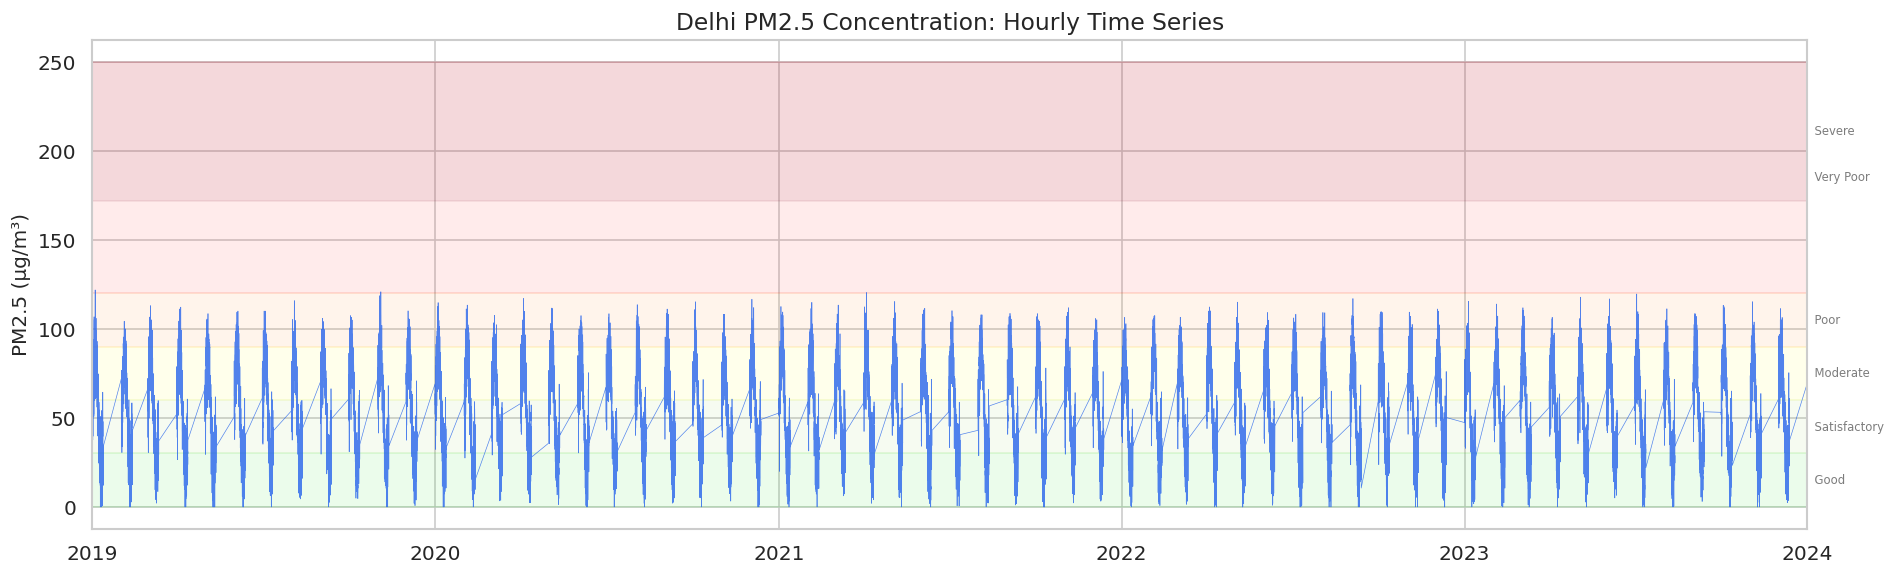

In [ ]:
# Full Time Series Plot
target = "pm25"

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df.index, df[target], linewidth=0.4, alpha=0.8, color="#2563EB")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("Delhi PM2.5 Concentration: Hourly Time Series")

# Add AQI category bands
aqi_bands = [
    (0, 30, "#00E400", "Good"),
    (30, 60, "#92D050", "Satisfactory"),
    (60, 90, "#FFFF00", "Moderate"),
    (90, 120, "#FF7E00", "Poor"),
    (120, 250, "#FF0000", "Very Poor"),
    (250, df[target].max() + 50, "#7E0023", "Severe"),
]
for low, high, color, label in aqi_bands:
    ax.axhspan(low, high, alpha=0.08, color=color)
    ax.text(df.index[-1], (low + high) / 2, f"  {label}", fontsize=7,
            va="center", alpha=0.6)

ax.set_xlim(df.index.min(), df.index.max())
plt.tight_layout()
plt.show()

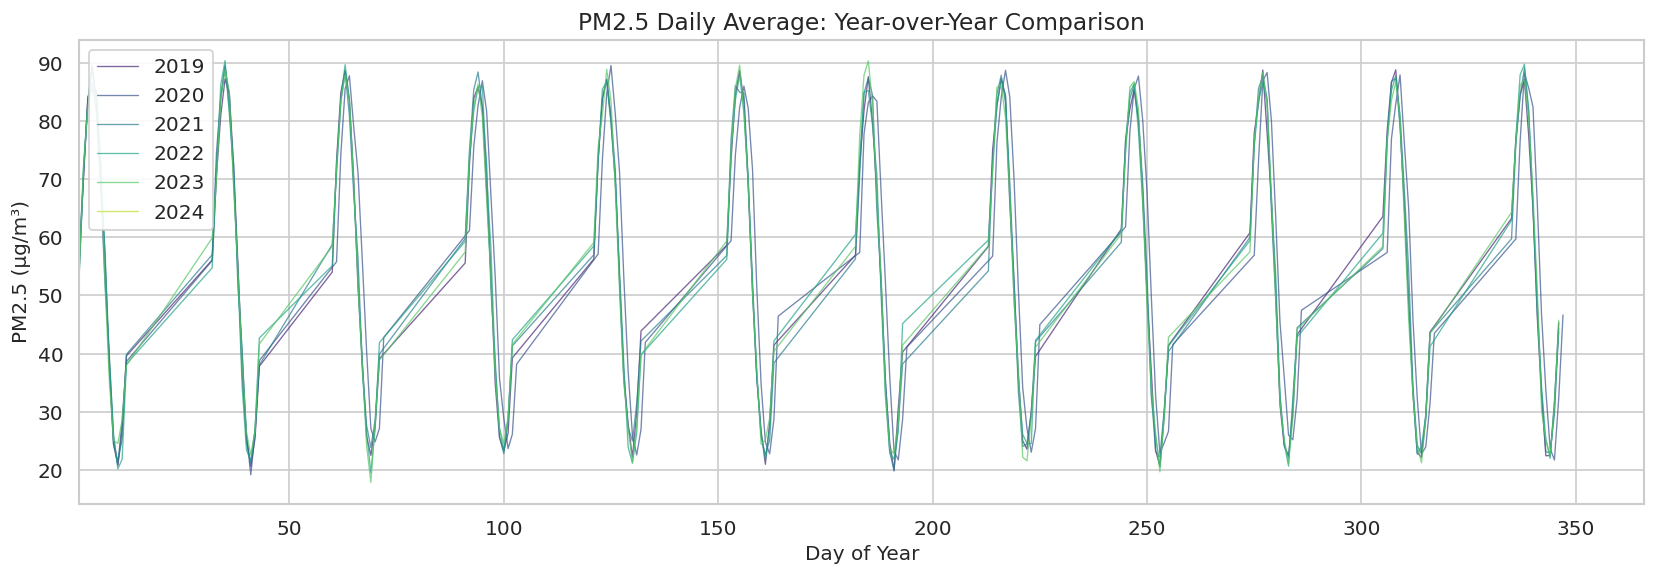

In [ ]:
# Yearly Overlay
fig, ax = plt.subplots(figsize=(14, 5))

df["year"] = df.index.year
df["day_of_year"] = df.index.dayofyear

daily = df.groupby(["year", "day_of_year"])[target].mean().reset_index()

colors = plt.cm.viridis(np.linspace(0.1, 0.9, daily["year"].nunique()))
for i, (year, group) in enumerate(daily.groupby("year")):
    ax.plot(group["day_of_year"], group[target], label=str(year),
            linewidth=0.8, alpha=0.7, color=colors[i])

ax.set_xlabel("Day of Year")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("PM2.5 Daily Average: Year-over-Year Comparison")
ax.legend(loc="upper left", framealpha=0.9)
ax.set_xlim(1, 366)
plt.tight_layout()
plt.show()

In [ ]:
# Clean up temp columns
df = df.drop(columns=["year", "day_of_year"], errors="ignore")

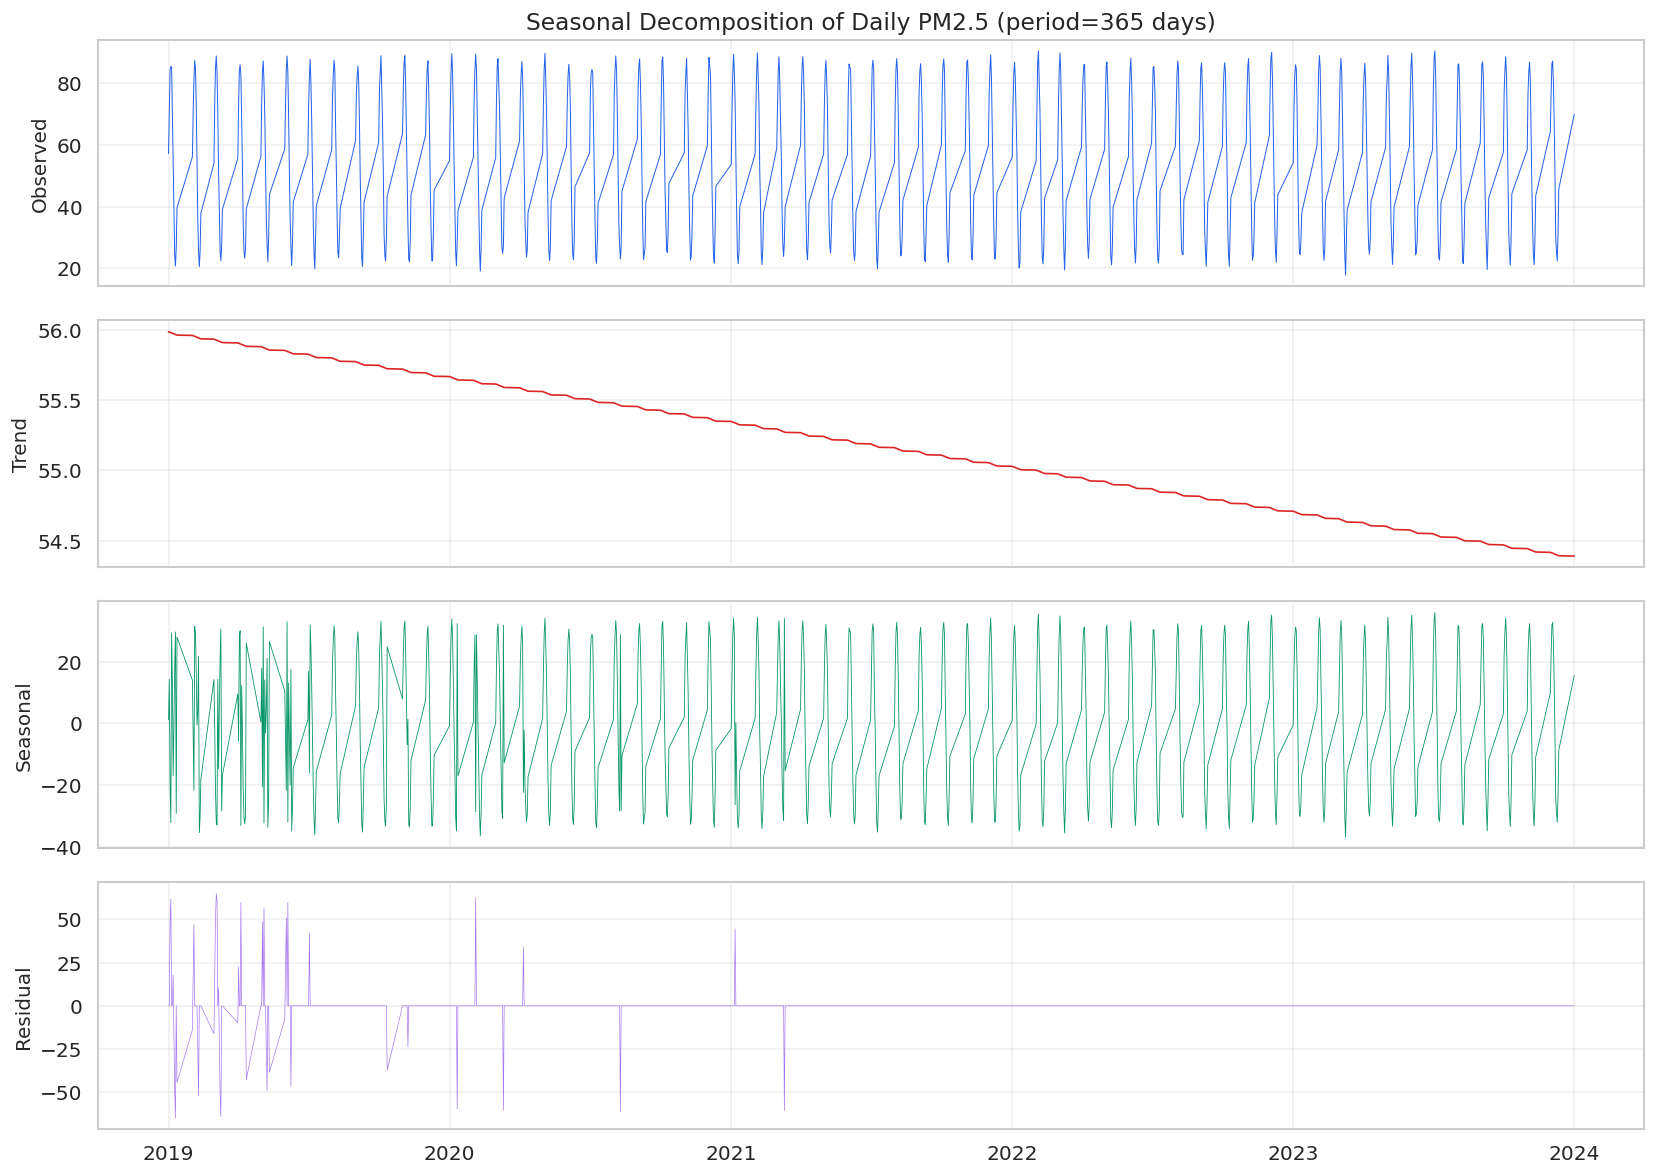

In [ ]:
# Seasonal Decomposition
# STL Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL

# Use daily resampled data for cleaner decomposition
daily_target = df[target].resample("1D").mean().dropna()
stl = STL(daily_target, period=365, robust=True)
decomp = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(decomp.observed, linewidth=0.6, color="#2563EB")
axes[0].set_ylabel("Observed")
axes[0].set_title("Seasonal Decomposition of Daily PM2.5 (period=365 days)")

axes[1].plot(decomp.trend, linewidth=1.0, color="#DC2626")
axes[1].set_ylabel("Trend")

axes[2].plot(decomp.seasonal, linewidth=0.5, color="#059669")
axes[2].set_ylabel("Seasonal")

axes[3].plot(decomp.resid, linewidth=0.4, color="#7C3AED", alpha=0.7)
axes[3].set_ylabel("Residual")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Temporal Patterns

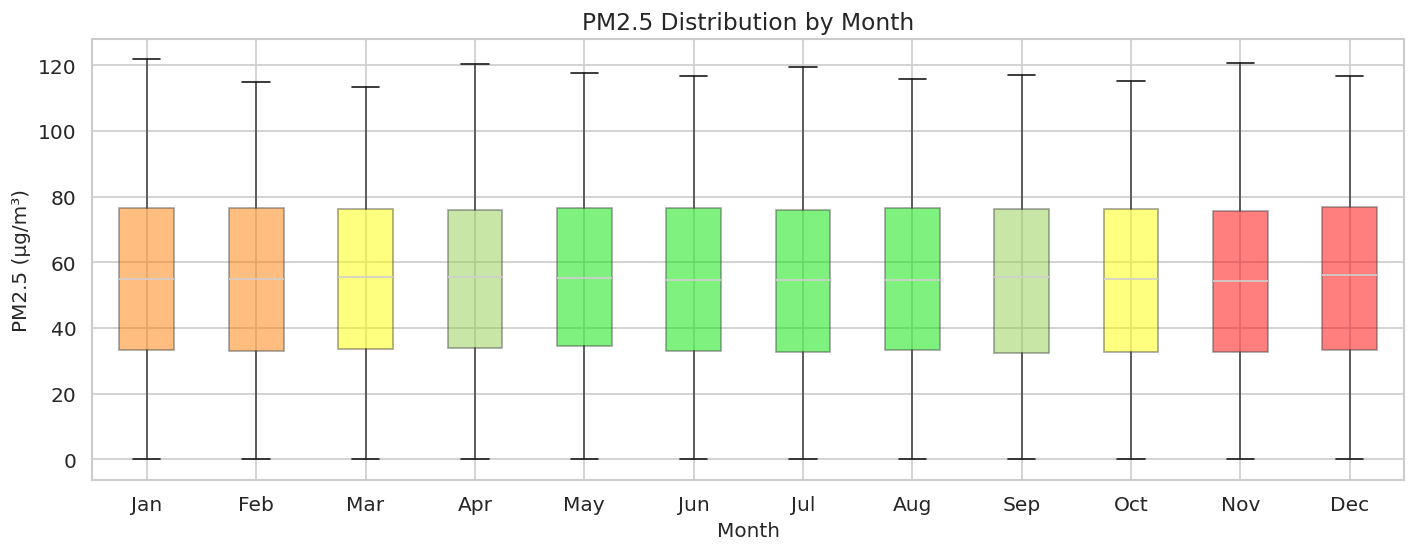

In [ ]:
# Monthly Distribution
df["month"] = df.index.month

fig, ax = plt.subplots(figsize=(12, 5))
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

bp = df.boxplot(column=target, by="month", ax=ax, showfliers=False,
                patch_artist=True, return_type="dict")


month_colors = ["#FF7E00", "#FF7E00", "#FFFF00", "#92D050", "#00E400", "#00E400",
                "#00E400", "#00E400", "#92D050", "#FFFF00", "#FF0000", "#FF0000"]

for patch, color in zip(bp[target]["boxes"], month_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)

ax.set_xticklabels(month_names)
ax.set_xlabel("Month")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("PM2.5 Distribution by Month")
fig.suptitle("")
plt.tight_layout()
plt.show()

In [ ]:
print("Monthly PM2.5 Statistics:")
monthly_stats = df.groupby("month")[target].agg(["mean", "median", "std", "max"])
monthly_stats.index = month_names
print(monthly_stats.round(1).to_string())

Monthly PM2.5 Statistics:
     mean  median   std    max
Jan  54.7    55.0  26.2  121.9
Feb  55.0    54.9  26.4  114.9
Mar  55.2    55.5  25.8  113.4
Apr  55.3    55.5  25.6  120.4
May  55.2    55.2  25.8  117.8
Jun  55.2    54.7  26.1  116.8
Jul  54.5    54.5  26.3  119.6
Aug  54.8    54.5  25.9  115.8
Sep  54.7    55.5  26.2  117.0
Oct  55.0    55.0  25.9  115.2
Nov  54.6    54.3  26.0  120.8
Dec  55.2    56.1  26.2  116.6


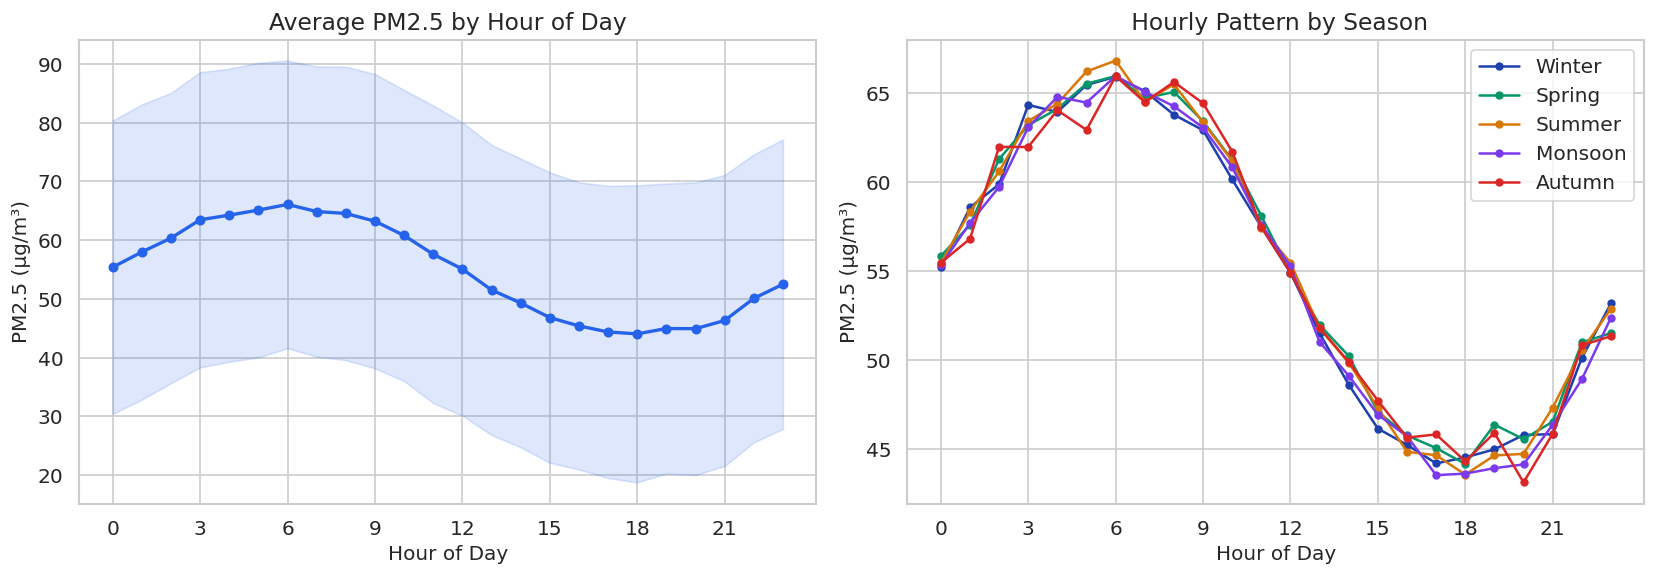

In [ ]:
# Hourly Pattern
df["hour"] = df.index.hour

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall hourly pattern
hourly_mean = df.groupby("hour")[target].mean()
hourly_std = df.groupby("hour")[target].std()

axes[0].plot(hourly_mean.index, hourly_mean.values, "o-", color="#2563EB",
             linewidth=2, markersize=5)
axes[0].fill_between(hourly_mean.index,
                      hourly_mean - hourly_std,
                      hourly_mean + hourly_std,
                      alpha=0.15, color="#2563EB")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].set_title("Average PM2.5 by Hour of Day")
axes[0].set_xticks(range(0, 24, 3))

# Hourly pattern by season
df["season"] = df["month"].map({
    1: "Winter", 2: "Winter", 3: "Spring",
    4: "Spring", 5: "Summer", 6: "Summer",
    7: "Monsoon", 8: "Monsoon", 9: "Monsoon",
    10: "Autumn", 11: "Winter", 12: "Winter"
})

season_colors = {
    "Winter": "#1E40AF", "Spring": "#059669",
    "Summer": "#D97706", "Monsoon": "#7C3AED",
    "Autumn": "#DC2626"
}

for season, color in season_colors.items():
    mask = df["season"] == season
    hourly_season = df[mask].groupby("hour")[target].mean()
    axes[1].plot(hourly_season.index, hourly_season.values, "o-",
                 label=season, color=color, linewidth=1.5, markersize=4)

axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].set_title(" Hourly Pattern by Season")
axes[1].legend()
axes[1].set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.show()

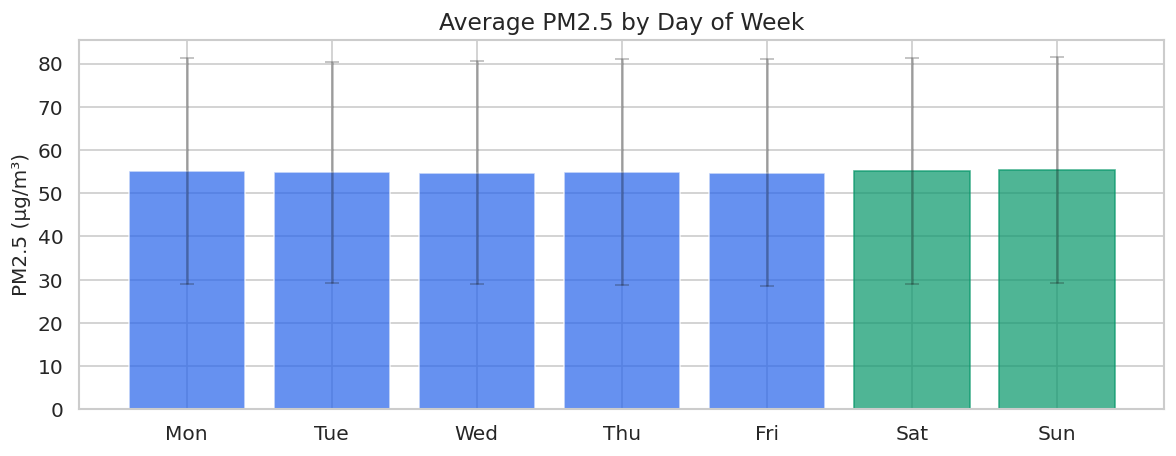

In [ ]:
# Day of Week Pattern
df["dayofweek"] = df.index.dayofweek
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(10, 4))
dow_mean = df.groupby("dayofweek")[target].mean()
dow_std = df.groupby("dayofweek")[target].std()

bars = ax.bar(range(7), dow_mean.values, color="#2563EB", alpha=0.7,
              yerr=dow_std.values, capsize=4, error_kw={"alpha": 0.3})

# Highlight weekend
bars[5].set_color("#059669")
bars[6].set_color("#059669")

ax.set_xticks(range(7))
ax.set_xticklabels(dow_names)
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("Average PM2.5 by Day of Week")
plt.tight_layout()
plt.show()

#Autocorrelation Analysis

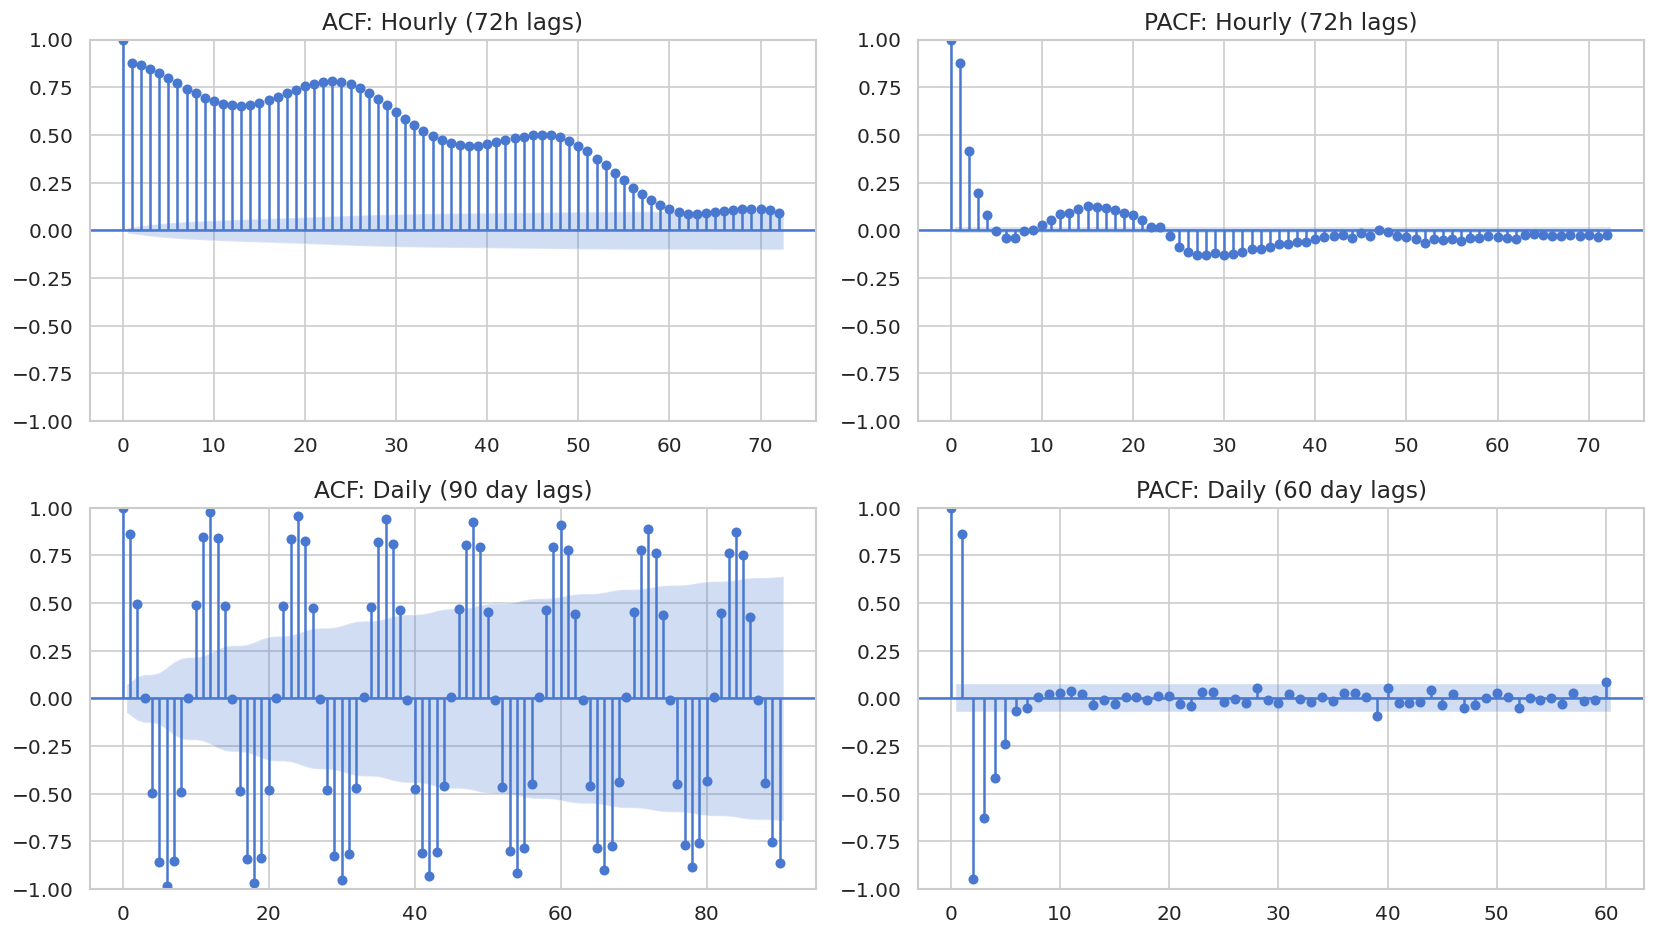

In [ ]:
# ACF and PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Use hourly data
hourly_target = df[target].dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Hourly ACF: look for 24h cycle
plot_acf(hourly_target, lags=72, ax=axes[0, 0], alpha=0.05,
         title="ACF: Hourly (72h lags)")

# Hourly PACF
plot_pacf(hourly_target, lags=72, ax=axes[0, 1], alpha=0.05,
          method="ywm", title="PACF: Hourly (72h lags)")

# Daily ACF: look for weekly + yearly cycles
plot_acf(daily_target, lags=90, ax=axes[1, 0], alpha=0.05,
         title="ACF: Daily (90 day lags)")

# Daily PACF
plot_pacf(daily_target, lags=60, ax=axes[1, 1], alpha=0.05,
          method="ywm", title="PACF: Daily (60 day lags)")

plt.tight_layout()
plt.show()

#Feature Correlations

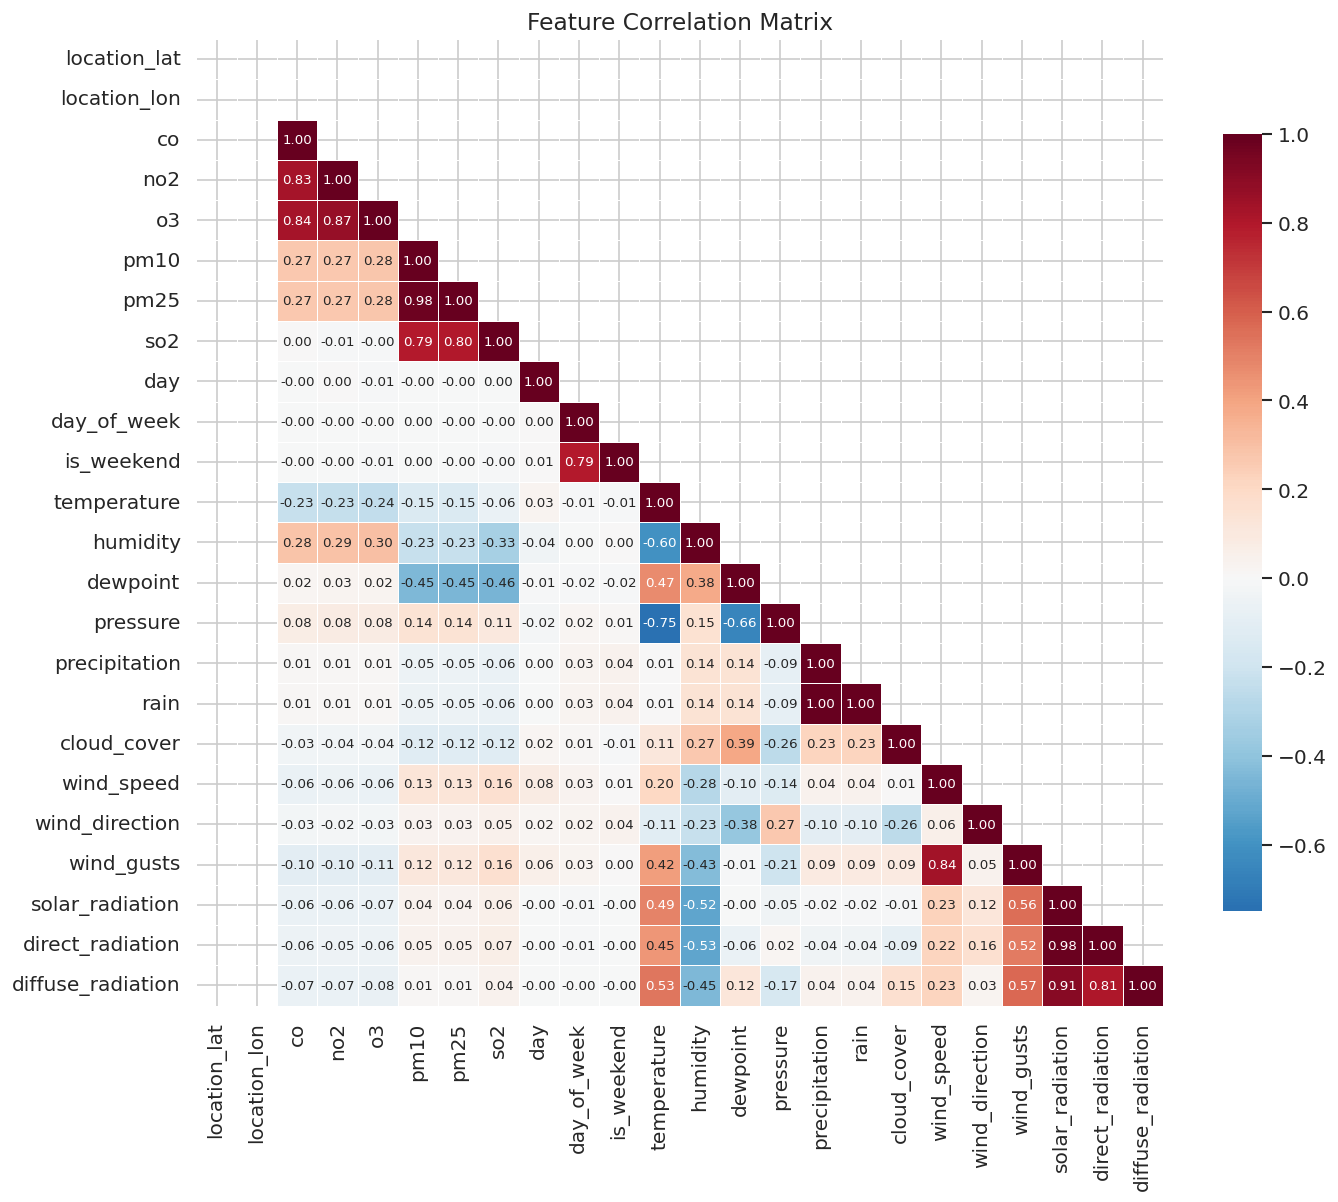

In [ ]:
# Correlation Heatmap
feature_cols = [c for c in df.columns if c not in
                ["month", "hour", "dayofweek", "season", "year", "day_of_year",
                 "aqi", "aqi_bucket"]]
corr_df = df[feature_cols].select_dtypes(include=[np.number])

if corr_df.shape[1] > 2:
    corr_matrix = corr_df.corr()

    fig, ax = plt.subplots(figsize=(12, 10))

    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
                cmap="RdBu_r", center=0, ax=ax,
                square=True, linewidths=0.5,
                cbar_kws={"shrink": 0.8},
                annot_kws={"size": 8})

    ax.set_title("Feature Correlation Matrix", fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
# Print top correlations with target
if target in corr_matrix.columns:
        target_corr = corr_matrix[target].drop(target).sort_values(
            key=abs, ascending=False
        )
        print(f"Top correlations with {target}:")
        for feat, corr_val in target_corr.items():
            sign = "+" if corr_val > 0 else "-"
            print(f"  {feat:25s} {sign}{abs(corr_val):.3f}  {bar}")

Top correlations with pm25:
  pm10                      +0.977  
  so2                       +0.798  
  dewpoint                  -0.451  
  o3                        +0.278  
  co                        +0.273  
  no2                       +0.270  
  humidity                  -0.229  
  temperature               -0.146  
  pressure                  +0.140  
  wind_speed                +0.130  
  cloud_cover               -0.124  
  wind_gusts                +0.115  
  precipitation             -0.055  
  rain                      -0.055  
  direct_radiation          +0.046  
  solar_radiation           +0.036  
  wind_direction            +0.034  
  diffuse_radiation         +0.011  
  is_weekend                -0.002  
  day                       -0.002  
  day_of_week               -0.001  
  location_lat              -nan  
  location_lon              -nan  


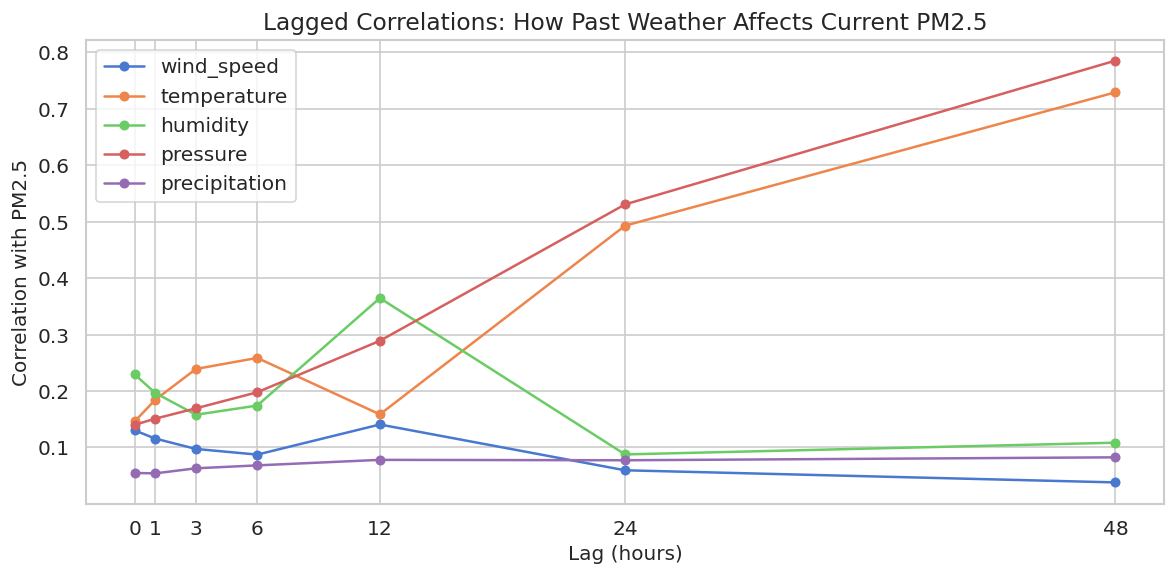

In [ ]:
# Lagged Correlations (Weather -> PM2.5)
weather_features = [c for c in ["wind_speed", "temperature", "humidity",
                                "pressure", "precipitation"] if c in df.columns]

if weather_features and target in df.columns:

    lags = [0, 1, 3, 6, 12, 24, 48]
    lag_results = []

    for feat in weather_features:
        for lag in lags:
            corr = df[target].corr(df[feat].shift(lag))
            lag_results.append({"feature": feat, "lag_hours": lag, "correlation": corr})

    lag_df = pd.DataFrame(lag_results)

    fig, ax = plt.subplots(figsize=(10, 5))
    for feat in weather_features:
        subset = lag_df[lag_df["feature"] == feat]
        ax.plot(subset["lag_hours"], subset["correlation"].abs(),
                "o-", label=feat, linewidth=1.5, markersize=5)

    ax.set_xlabel("Lag (hours)")
    ax.set_ylabel("Correlation with PM2.5")
    ax.set_title("Lagged Correlations: How Past Weather Affects Current PM2.5")
    ax.legend()
    ax.set_xticks(lags)
    plt.tight_layout()
    plt.show()

In [ ]:
# Best lag per feature
print("Optimal lag per weather feature:")
for feat in weather_features:
    subset = lag_df[lag_df["feature"] == feat]
    best = subset.loc[subset["correlation"].abs().idxmax()]
    print(f"  {feat:20s} : best lag = {int(best['lag_hours'])}h "
          f"(r = {best['correlation']:.3f})")

Optimal lag per weather feature:
  wind_speed           : best lag = 12h (r = 0.141)
  temperature          : best lag = 48h (r = -0.729)
  humidity             : best lag = 12h (r = -0.365)
  pressure             : best lag = 48h (r = 0.785)
  precipitation        : best lag = 48h (r = -0.083)


#Wind Analysis

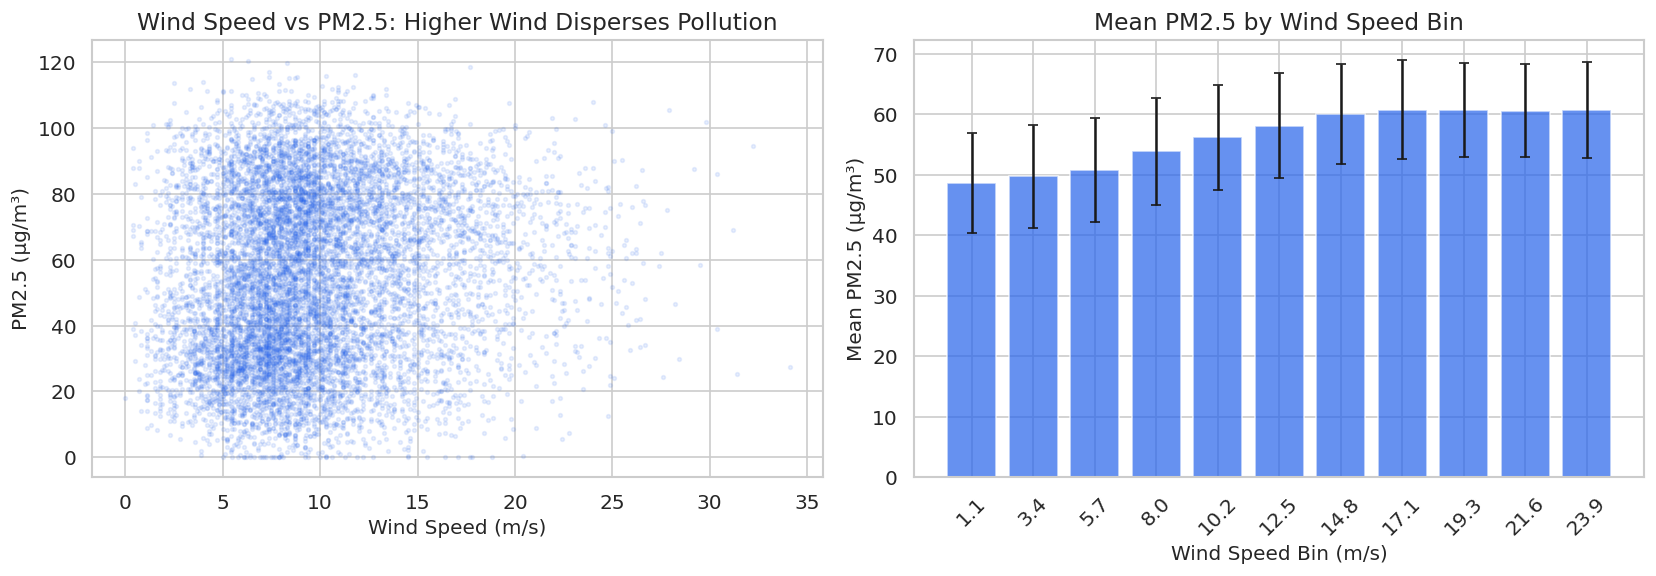

In [ ]:
# Wind Speed vs PM2.5
if "wind_speed" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter plot
    sample = df.dropna(subset=[target, "wind_speed"]).sample(
        min(10000, len(df)), random_state=42
    )
    axes[0].scatter(sample["wind_speed"], sample[target],
                    alpha=0.1, s=5, color="#2563EB")
    axes[0].set_xlabel("Wind Speed (m/s)")
    axes[0].set_ylabel("PM2.5 (µg/m³)")
    axes[0].set_title("Wind Speed vs PM2.5: Higher Wind Disperses Pollution")

    # Binned mean
    df["wind_bin"] = pd.cut(df["wind_speed"], bins=15)
    wind_binned = df.groupby("wind_bin", observed=True)[target].agg(["mean", "std", "count"])
    wind_binned = wind_binned[wind_binned["count"] > 50]  # drop low-count bins

    x = range(len(wind_binned))
    axes[1].bar(x, wind_binned["mean"], color="#2563EB", alpha=0.7,
                yerr=wind_binned["std"] / 3, capsize=3)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(
        [f"{iv.mid:.1f}" for iv in wind_binned.index], rotation=45
    )
    axes[1].set_xlabel("Wind Speed Bin (m/s)")
    axes[1].set_ylabel("Mean PM2.5 (µg/m³)")
    axes[1].set_title("Mean PM2.5 by Wind Speed Bin")

    df = df.drop(columns=["wind_bin"], errors="ignore")
    plt.tight_layout()
    plt.show()

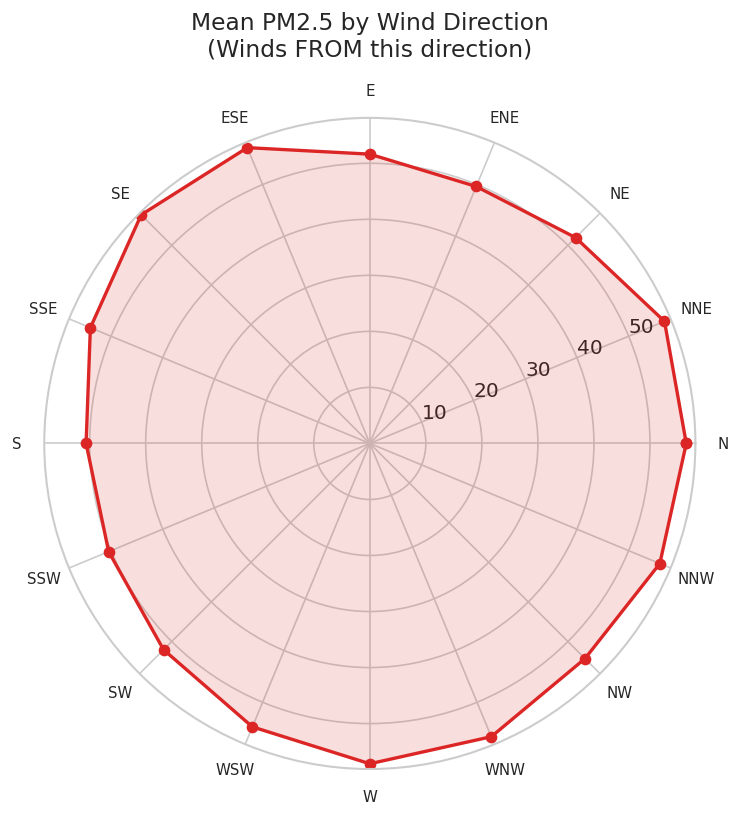

In [ ]:
# Wind Rose (Direction vs PM2.5)
if "wind_direction" in df.columns and "wind_speed" in df.columns:
    # Bin wind direction into 16 compass sectors
    dir_bins = np.arange(0, 361, 22.5)
    dir_labels = ["N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE",
                  "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW"]

    df["wind_sector"] = pd.cut(
        df["wind_direction"] % 360, bins=dir_bins, labels=dir_labels,
        include_lowest=True
    )

    sector_pm25 = df.groupby("wind_sector", observed=True)[target].mean()

    # Polar plot
    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, polar=True)

    angles = np.linspace(0, 2 * np.pi, len(sector_pm25), endpoint=False)
    values = sector_pm25.values
    values = np.append(values, values[0])  # close the polygon
    angles = np.append(angles, angles[0])

    ax.plot(angles, values, "o-", color="#DC2626", linewidth=2)
    ax.fill(angles, values, alpha=0.15, color="#DC2626")
    ax.set_thetagrids(np.degrees(angles[:-1]), dir_labels, fontsize=9)
    ax.set_title("Mean PM2.5 by Wind Direction\n(Winds FROM this direction)", y=1.08)

    plt.tight_layout()
    plt.show()

In [ ]:
df = df.drop(columns=["wind_sector"], errors="ignore")

#Extreme Event Analysis

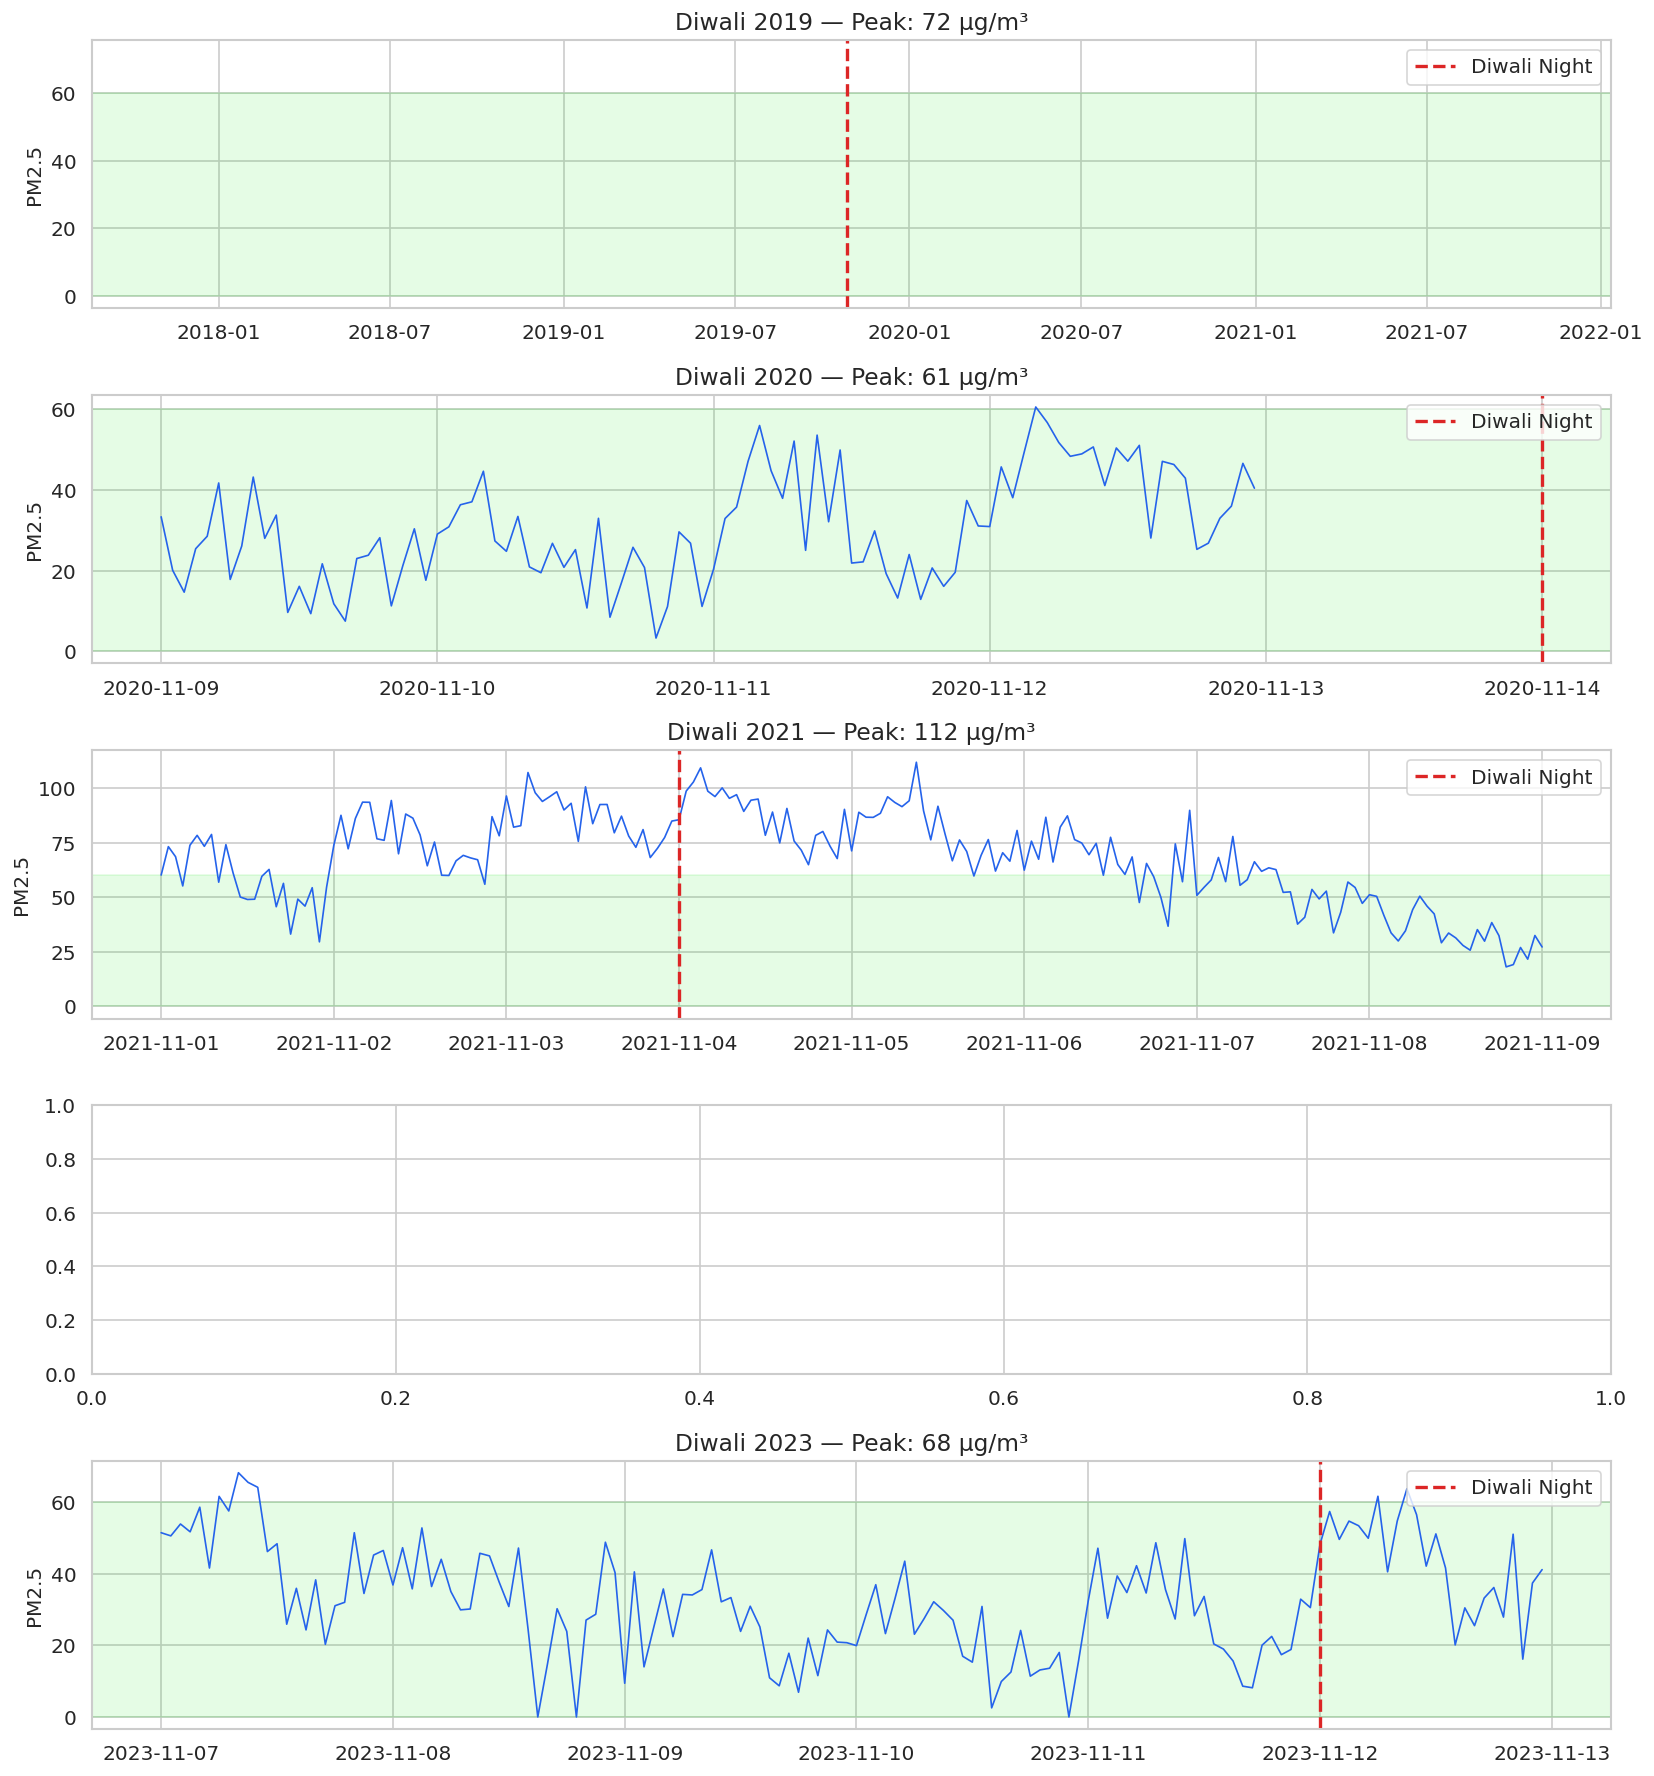

In [ ]:
# Diwali Impact
# Approximate Diwali dates
diwali_dates = pd.to_datetime([
    "2019-10-27", "2020-11-14", "2021-11-04",
    "2022-10-24", "2023-11-12", "2024-11-01"
])

# Filter to dates within our data range
diwali_dates = [d for d in diwali_dates
                if df.index.min() <= d <= df.index.max()]

if diwali_dates:
    fig, axes = plt.subplots(len(diwali_dates), 1,
                              figsize=(14, 3 * len(diwali_dates)), sharex=False)
    if len(diwali_dates) == 1:
        axes = [axes]

    for i, diwali in enumerate(diwali_dates):
        window_start = diwali - pd.Timedelta(days=5)
        window_end = diwali + pd.Timedelta(days=5)

        window = df.loc[window_start:window_end, target].dropna()

        if len(window) > 0:
            axes[i].plot(window.index, window.values, linewidth=1.0, color="#2563EB")
            axes[i].axvline(diwali, color="#DC2626", linestyle="--",
                           linewidth=2, label="Diwali Night")
            axes[i].axhspan(0, 60, alpha=0.1, color="#00E400")
            axes[i].set_ylabel("PM2.5")
            axes[i].set_title(f"Diwali {diwali.year} — "
                             f"Peak: {window.max():.0f} µg/m³")
            axes[i].legend(loc="upper right")

    plt.tight_layout()
    plt.show()

In [ ]:
# Check data availability for each Diwali window
for d in diwali_dates:
    window_start = d - pd.Timedelta(days=5)
    window_end = d + pd.Timedelta(days=5)
    count = len(df.loc[window_start:window_end])
    print(f"Diwali {d.year}: {count} data points found between {window_start.date()} and {window_end.date()}")

Diwali 2019: 1 data points found between 2019-10-22 and 2019-11-01
Diwali 2020: 96 data points found between 2020-11-09 and 2020-11-19
Diwali 2021: 193 data points found between 2021-10-30 and 2021-11-09
Diwali 2022: 0 data points found between 2022-10-19 and 2022-10-29
Diwali 2023: 144 data points found between 2023-11-07 and 2023-11-17


#Distribution Analysis

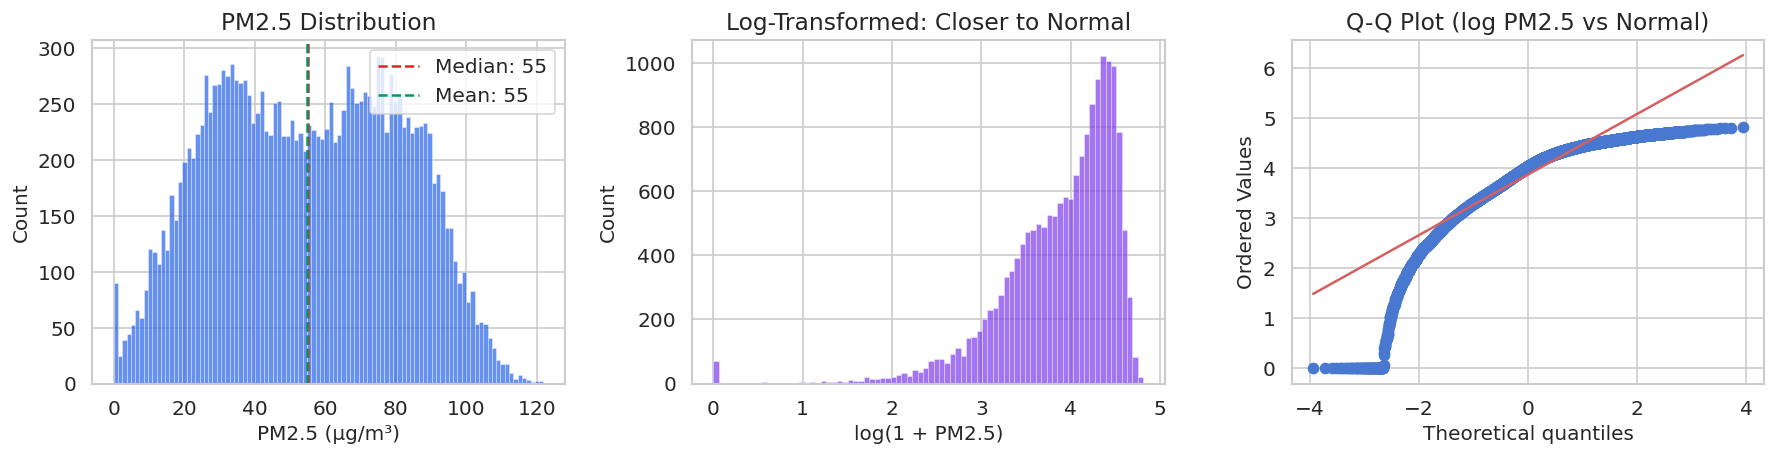

In [ ]:
# PM2.5 Distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(df[target].dropna(), bins=100, color="#2563EB", alpha=0.7,
             edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("PM2.5 (µg/m³)")
axes[0].set_ylabel("Count")
axes[0].set_title("PM2.5 Distribution")
axes[0].axvline(df[target].median(), color="#DC2626", linestyle="--",
                label=f"Median: {df[target].median():.0f}")
axes[0].axvline(df[target].mean(), color="#059669", linestyle="--",
                label=f"Mean: {df[target].mean():.0f}")
axes[0].legend()

# Log-transformed
log_target = np.log1p(df[target].dropna())
axes[1].hist(log_target, bins=80, color="#7C3AED", alpha=0.7,
             edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("log(1 + PM2.5)")
axes[1].set_ylabel("Count")
axes[1].set_title("Log-Transformed: Closer to Normal")

# QQ plot
from scipy import stats
stats.probplot(log_target, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot (log PM2.5 vs Normal)")

plt.tight_layout()
plt.show()